# S6E2 Gradient Boosted Trees
XGBoost · LightGBM · CatBoost — default parameters, then tune the best performer.

| | XGBoost | LightGBM | CatBoost |
|---|---|---|---|
| **Tree growth** | Level-wise | Leaf-wise (fastest) | Symmetric (oblivious) |
| **Categoricals** | Manual encoding | Native (limited) | Native (best-in-class) |
| **Overfitting** | Good regularization | Can overfit small data | Very resistant |
| **Tuning effort** | Many params | Many params | Fewer, good defaults |

## Imports & Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

KAGGLE_DATA = Path("/kaggle/input/playground-series-s6e2")
LOCAL_DATA  = Path("data")
DATA_DIR    = KAGGLE_DATA if KAGGLE_DATA.exists() else LOCAL_DATA

def prep(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)
    if "heart_disease" in df.columns:
        df["heart_disease"] = df["heart_disease"].map({"Absence": 0, "Presence": 1})
    return df

train = prep(pd.read_csv(DATA_DIR / "train.csv"))
test  = prep(pd.read_csv(DATA_DIR / "test.csv"))
ss    = pd.read_csv(DATA_DIR / "sample_submission.csv")

FEATURES     = [c for c in train.columns if c not in ["heart_disease", "id"]]
CAT_FEATURES = ["sex", "chest_pain_type", "fbs_over_120", "ekg_results",
                "exercise_angina", "slope_of_st", "number_of_vessels_fluro", "thallium"]

X = train[FEATURES]; y = train["heart_disease"]; X_test = test[FEATURES]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Train: {X.shape}  Test: {X_test.shape}")

Train: (630000, 13)  Test: (270000, 13)


## Helper: CV for CatBoost
CatBoost can't be cloned by sklearn — wrap in a manual loop.

In [2]:
def catboost_cv(model_params, X, y, cv):
    """Manual 5-fold CV for CatBoost using column-name cat_features."""
    accs, aucs = [], []
    for tr_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        m = cb.CatBoostClassifier(**model_params)
        m.fit(X_tr, y_tr)
        accs.append(accuracy_score(y_val, m.predict(X_val)))
        aucs.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))
    return np.mean(accs), np.mean(aucs)

## XGBoost

In [3]:
xgb_params = dict(n_estimators=500, learning_rate=0.1, max_depth=6,
                  subsample=0.8, colsample_bytree=0.8,
                  eval_metric="logloss", device="cuda", random_state=42, n_jobs=-1)

xgb_acc = cross_val_score(xgb.XGBClassifier(**xgb_params), X, y, cv=cv, scoring="accuracy").mean()
xgb_auc = cross_val_score(xgb.XGBClassifier(**xgb_params), X, y, cv=cv, scoring="roc_auc").mean()
print(f"XGBoost   cv_acc={xgb_acc:.4f}  cv_auc={xgb_auc:.4f}")

XGBoost   cv_acc=0.8883  cv_auc=0.9549


## LightGBM

In [4]:
lgb_params = dict(n_estimators=500, learning_rate=0.1, num_leaves=31,
                  subsample=0.8, colsample_bytree=0.8,
                  device="gpu", random_state=42, n_jobs=-1, verbose=-1)

lgb_acc = cross_val_score(lgb.LGBMClassifier(**lgb_params), X, y, cv=cv, scoring="accuracy").mean()
lgb_auc = cross_val_score(lgb.LGBMClassifier(**lgb_params), X, y, cv=cv, scoring="roc_auc").mean()
print(f"LightGBM  cv_acc={lgb_acc:.4f}  cv_auc={lgb_auc:.4f}")

LightGBM  cv_acc=0.8884  cv_auc=0.9551


## CatBoost

In [5]:
cat_params = dict(iterations=500, learning_rate=0.1, depth=6,
                  task_type="GPU", cat_features=CAT_FEATURES, random_state=42, verbose=0)

cat_acc, cat_auc = catboost_cv(cat_params, X, y, cv)
print(f"CatBoost  cv_acc={cat_acc:.4f}  cv_auc={cat_auc:.4f}")

CatBoost  cv_acc=0.8889  cv_auc=0.9554


## Comparison

           model   cv_acc   cv_auc      lb
catboost_default 0.888878 0.955403     NaN
    lgbm_default 0.888395 0.955086     NaN
     xgb_default 0.888257 0.954882     NaN
      lr_default 0.883100 0.950500 0.87724
      dt_depth10 0.881200 0.948800 0.87600
   thallium_only 0.805200 0.799000 0.79435


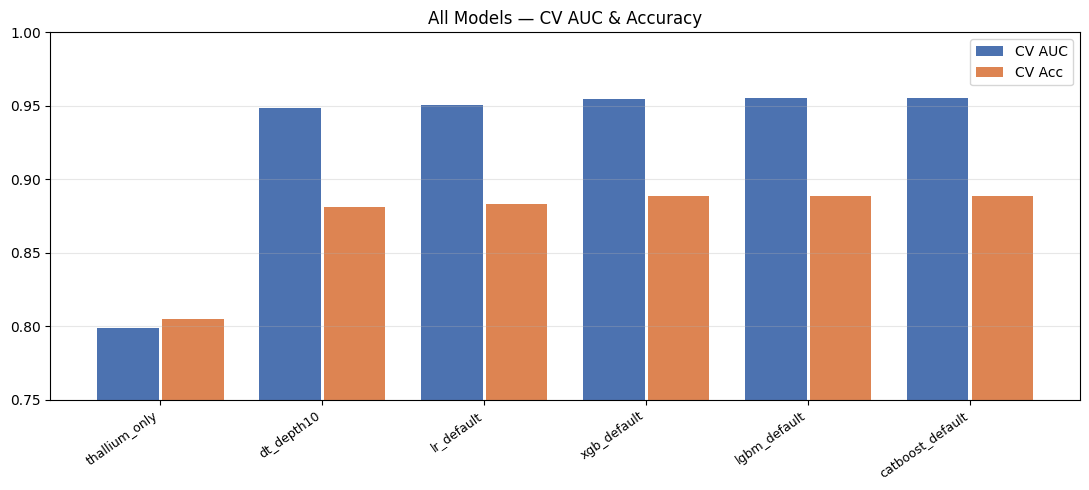

In [6]:
results = pd.DataFrame([
    {"model": "thallium_only",    "cv_acc": 0.8052, "cv_auc": 0.7990, "lb": 0.79435},
    {"model": "dt_depth10",       "cv_acc": 0.8812, "cv_auc": 0.9488, "lb": 0.87600},
    {"model": "lr_default",       "cv_acc": 0.8831, "cv_auc": 0.9505, "lb": 0.87724},
    {"model": "xgb_default",      "cv_acc": xgb_acc, "cv_auc": xgb_auc, "lb": None},
    {"model": "lgbm_default",     "cv_acc": lgb_acc, "cv_auc": lgb_auc, "lb": None},
    {"model": "catboost_default", "cv_acc": cat_acc, "cv_auc": cat_auc, "lb": None},
])
print(results.sort_values("cv_auc", ascending=False).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(results))
ax.bar([i-.2 for i in x], results["cv_auc"], width=.38, label="CV AUC",  color="#4C72B0")
ax.bar([i+.2 for i in x], results["cv_acc"], width=.38, label="CV Acc",  color="#DD8452")
ax.set_xticks(list(x)); ax.set_xticklabels(results["model"], rotation=35, ha="right", fontsize=9)
ax.set_ylim(0.75, 1.0); ax.legend(); ax.grid(axis="y", alpha=0.3)
ax.set_title("All Models — CV AUC & Accuracy")
plt.tight_layout(); plt.show()

## Feature Importances

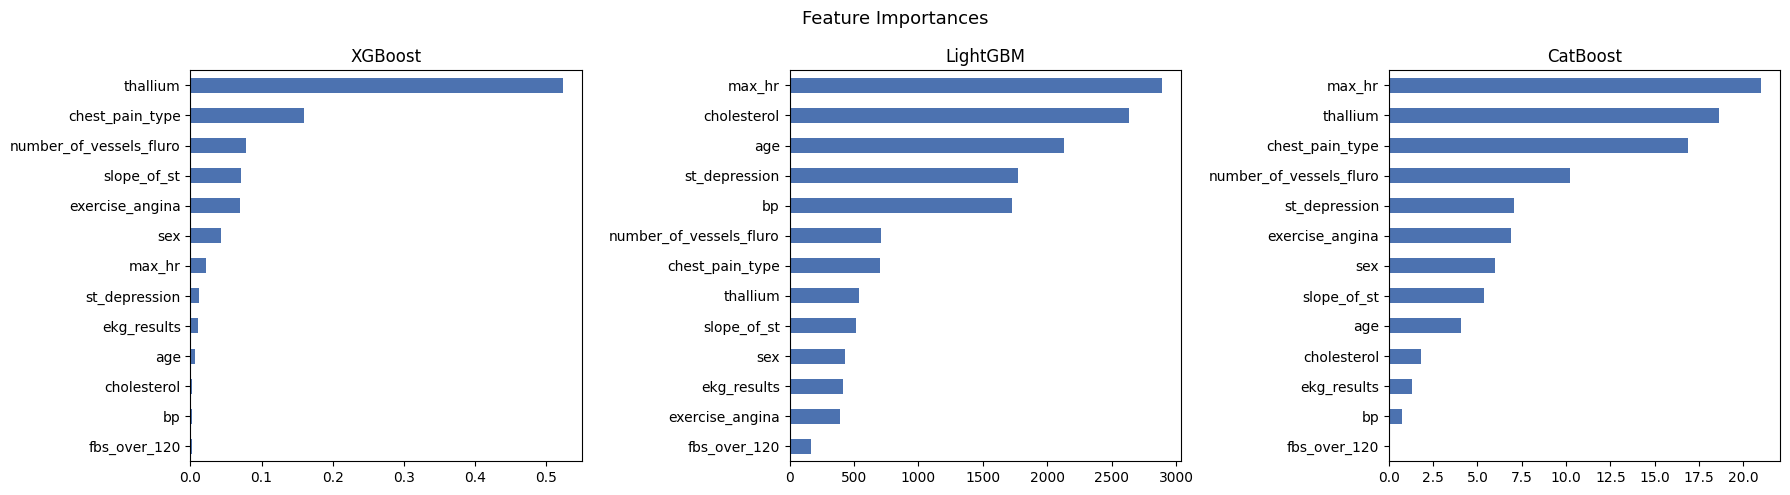

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# XGBoost
m_xgb = xgb.XGBClassifier(**xgb_params).fit(X, y)
pd.Series(m_xgb.feature_importances_, index=FEATURES).sort_values().plot(
    kind="barh", ax=axes[0], color="#4C72B0"); axes[0].set_title("XGBoost")

# LightGBM
m_lgb = lgb.LGBMClassifier(**lgb_params).fit(X, y)
pd.Series(m_lgb.feature_importances_, index=FEATURES).sort_values().plot(
    kind="barh", ax=axes[1], color="#4C72B0"); axes[1].set_title("LightGBM")

# CatBoost
m_cat = cb.CatBoostClassifier(**cat_params).fit(X, y)
pd.Series(m_cat.feature_importances_, index=FEATURES).sort_values().plot(
    kind="barh", ax=axes[2], color="#4C72B0"); axes[2].set_title("CatBoost")

plt.suptitle("Feature Importances", fontsize=13)
plt.tight_layout(); plt.show()

## Submit All Three

In [8]:
def submit(model, name, cv_acc, cv_auc):
    model.fit(X, y)
    sub = ss.copy()
    sub["Heart Disease"] = model.predict_proba(X_test)[:, 1]
    fname = f"submissions/{name}.csv"
    desc  = f"{name} | cv_acc={cv_acc:.4f} | cv_auc={cv_auc:.4f}"
    sub.to_csv(fname, index=False)
    r = subprocess.run(
        ["kaggle", "competitions", "submit", "-c", "playground-series-s6e2",
         "-f", fname, "-m", desc],
        capture_output=True, text=True
    )
    status = "submitted" if "successfully" in r.stdout.lower() else r.stdout.strip()[:60]
    print(f"{name}: {status}")
    print(f"  desc: {desc}")

submit(xgb.XGBClassifier(**xgb_params),        "xgb_default",      xgb_acc, xgb_auc)
submit(lgb.LGBMClassifier(**lgb_params),        "lgbm_default",     lgb_acc, lgb_auc)
submit(cb.CatBoostClassifier(**cat_params),     "catboost_default", cat_acc, cat_auc)

xgb_default: submitted
  desc: xgb_default | cv_acc=0.8883 | cv_auc=0.9549


lgbm_default: Warning: Looks like you're using an outdated API Version, pl
  desc: lgbm_default | cv_acc=0.8884 | cv_auc=0.9551


catboost_default: Warning: Looks like you're using an outdated API Version, pl
  desc: catboost_default | cv_acc=0.8889 | cv_auc=0.9554
